# Laboratorio 7 - Carga, armonización y calidad de datos

Esta sección prepara las bases de Personas de ENEIC para el análisis posterior. La conversión inicial desde Excel usa pandas; todas las validaciones, filtros y persistencia se realizan con PySpark.

In [1]:
from functools import reduce
import os
import sys
from pathlib import Path

# Spark debe iniciar sus workers con el mismo Python que ejecuta este kernel.
# Esta asignación debe ocurrir antes de crear la SparkSession.
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

import pandas as pd
from pyspark.sql import DataFrame, SparkSession, functions as F

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
spark_builder = (SparkSession.builder
    .master('local[1]')
    .appName('DS-LAB07')
    .config('spark.ui.enabled', 'false')
    .config('spark.python.worker.reuse', 'true')
    .config('spark.python.worker.connect.timeout', '120'))
if os.name == 'nt':
    # En Windows, este sistema de archivos Java permite guardar Parquet y modelos sin winutils.exe.
    filesystem_jar = PROJECT_ROOT / 'third_party' / 'hadoop-bare-naked-local-fs-0.1.0.jar'
    spark_builder = (spark_builder
        .config('spark.driver.extraClassPath', str(filesystem_jar))
        .config('spark.executor.extraClassPath', str(filesystem_jar))
        .config('spark.hadoop.fs.file.impl', 'com.globalmentor.apache.hadoop.fs.BareLocalFileSystem'))
spark = spark_builder.getOrCreate()
spark.sparkContext.setLogLevel('WARN')

LINK DEL REPO: https://github.com/jcdiegolopez/DS-LAB07

In [2]:
# Funciones de preparación. Todas las transformaciones analíticas se ejecutan en Spark.
RAW_COLUMNS = ['P05D01', 'P02A03', 'P05C07A', 'P05C07B', 'P05H01A', 'P03A03A', 'P05C16', 'DOMINIO', 'OCUPADOS', 'NUM_HOGAR', 'NUM_PERSONA', 'FACTOR', 'ANIO', 'TRIMESTRE']
NUMERIC_COLUMNS = ['P05D01', 'P02A03', 'P05C07A', 'P05C07B', 'P05H01A', 'FACTOR']
CATEGORICAL_COLUMNS = ['P03A03A', 'P05C16', 'DOMINIO', 'OCUPADOS']

def normalize_code(column):
    value = F.trim(column.cast('string'))
    return F.when(value.rlike(r'^[+-]?\d+\.0+$'), F.regexp_replace(value, r'\.0+$', '')).otherwise(value)

def numeric_value(column):
    value = F.regexp_replace(F.trim(column.cast('string')), ',', '')
    return F.when(value.rlike(r'^[+-]?(\d+(\.\d*)?|\.\d+)([eE][+-]?\d+)?$'), value.cast('double'))

def read_personas_excel(path, periodo_archivo, anio_archivo, trimestre_calendario):
    path = Path(path)
    source = pd.read_excel(path, usecols=lambda name: name in RAW_COLUMNS, dtype='string')
    missing = sorted(set(RAW_COLUMNS) - set(source.columns))
    if missing:
        raise ValueError(f'{path.name} no contiene las columnas requeridas: {missing}')
    source = source[RAW_COLUMNS]
    source['archivo_origen'] = path.name
    source['periodo_archivo'] = periodo_archivo
    source['anio_archivo'] = str(anio_archivo)
    source['trimestre_calendario'] = str(trimestre_calendario)
    # La conversión directa desde pandas evita crear un RDD de Python en Windows.
    return spark.createDataFrame(source.fillna(''))

def harmonize_types(frame):
    result = frame
    for name in NUMERIC_COLUMNS:
        result = result.withColumn(name, numeric_value(F.col(name)))
    for name in CATEGORICAL_COLUMNS + ['NUM_HOGAR', 'NUM_PERSONA', 'ANIO', 'TRIMESTRE']:
        result = result.withColumn(name, normalize_code(F.col(name)))
    return (result.withColumn('anio_archivo', F.col('anio_archivo').cast('int'))
        .withColumn('trimestre_calendario', F.col('trimestre_calendario').cast('int'))
        .withColumnRenamed('P05D01', 'salario_mensual').withColumnRenamed('P02A03', 'edad')
        .withColumnRenamed('P05C07A', 'antiguedad_anios').withColumnRenamed('P05C07B', 'antiguedad_meses')
        .withColumnRenamed('P05H01A', 'horas_semanales').withColumnRenamed('P03A03A', 'nivel_educativo')
        .withColumnRenamed('P05C16', 'categoria_ocupacional').withColumnRenamed('DOMINIO', 'dominio')
        .withColumnRenamed('OCUPADOS', 'ocupado'))

def union_frames(frames):
    if not frames:
        raise ValueError('No se proporcionaron DataFrames para unir.')
    return reduce(lambda left, right: left.unionByName(right, allowMissingColumns=True), frames)

def missing_report(frame, columns):
    total = frame.count()
    numeric_types = {'double', 'float', 'int', 'bigint', 'decimal'}
    types = dict(frame.dtypes)
    rows = []
    for name in columns:
        missing = F.col(name).isNull() | (F.trim(F.col(name).cast('string')) == '')
        if any(types[name].startswith(data_type) for data_type in numeric_types):
            missing = missing | F.isnan(F.col(name))
        rows.append((name, frame.where(missing).count()))
    return spark.createDataFrame([(name, missing, 100 * missing / total if total else 0.0) for name, missing in rows], ['variable', 'faltantes', 'porcentaje_faltantes'])

def categorize_values(frame, valid_codes):
    result = frame
    for name in ['nivel_educativo', 'categoria_ocupacional', 'dominio']:
        allowed = valid_codes.get(name)
        if not allowed:
            raise ValueError(f'Faltan códigos validados del diccionario para {name}.')
        result = result.withColumn(name, F.when(F.col(name).isin(*sorted(allowed)), F.col(name)).otherwise(F.lit('DESCONOCIDO')))
    return result

def filter_population(frame):
    stages = [
        ('edad_valida', F.col('edad').isNotNull() & ~F.isnan('edad') & (F.col('edad') >= 15)),
        ('ocupado', F.col('ocupado') == '1'),
        ('asalariado', F.col('categoria_ocupacional').isin('1', '2', '3', '4')),
        ('salario_positivo', F.col('salario_mensual').isNotNull() & ~F.isnan('salario_mensual') & (F.col('salario_mensual') > 0)),
        ('antiguedad_valida', F.col('antiguedad_anios').isNotNull() & ~F.isnan('antiguedad_anios') & (F.col('antiguedad_anios') >= 0) & F.col('antiguedad_meses').isNotNull() & ~F.isnan('antiguedad_meses') & (F.col('antiguedad_meses') >= 0) & (F.col('antiguedad_meses') <= 11) & (F.floor(F.col('antiguedad_meses')) == F.col('antiguedad_meses'))),
        ('antiguedad_no_mayor_edad', (F.col('antiguedad_anios') + F.col('antiguedad_meses') / 12) <= F.col('edad')),
        ('horas_validas', F.col('horas_semanales').isNotNull() & ~F.isnan('horas_semanales') & (F.col('horas_semanales') > 0) & (F.col('horas_semanales') <= 168)),
    ]
    current, report = frame, []
    for stage, condition in stages:
        before = current.count()
        current = current.where(condition)
        after = current.count()
        report.append((stage, before, after, before - after))
    prepared = current.withColumn('antiguedad', F.col('antiguedad_anios') + F.col('antiguedad_meses') / 12)
    return prepared, spark.createDataFrame(report, ['paso', 'registros_antes', 'registros_despues', 'registros_excluidos'])

def counts_by_file(before, after):
    initial = before.groupBy('archivo_origen').count().withColumnRenamed('count', 'antes_filtros')
    final = after.groupBy('archivo_origen').count().withColumnRenamed('count', 'despues_filtros')
    return initial.join(final, 'archivo_origen', 'left').fillna(0).orderBy('archivo_origen')

def duplicate_audit(frame):
    keys = ['periodo_archivo', 'NUM_HOGAR', 'NUM_PERSONA']
    repeated = frame.groupBy(*keys).count().where(F.col('count') > 1)
    repeated_rows = frame.join(repeated.select(*keys), keys, 'inner')
    compared = [name for name in frame.columns if name not in keys]
    signatures = repeated_rows.withColumn('firma_registro', F.sha2(F.concat_ws('||', *[F.coalesce(F.col(name).cast('string'), F.lit('<NULL>')) for name in compared]), 256))
    summary = signatures.groupBy(*keys).agg(F.count('*').alias('filas'), F.countDistinct('firma_registro').alias('versiones_distintas')).withColumn('clasificacion', F.when(F.col('versiones_distintas') == 1, 'repeticion_exacta').otherwise('conflicto'))
    return summary, repeated_rows

## Configuración de archivos

Actualizar las rutas con los nombres reales de los cinco archivos descargados. Cada período se asigna según el archivo de procedencia, no mediante la columna original `TRIMESTRE`.

In [3]:
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DICTIONARY_DIR = PROJECT_ROOT / 'data' / 'diccionarios'
FILES = {
    '2025T1': (RAW_DATA_DIR / 'Personas_ENEIC_T1_2025.xlsx', 2025, 1),
    '2025T2': (RAW_DATA_DIR / 'Personas-ENEIC-T2-2025.xlsx', 2025, 2),
    '2025T3': (RAW_DATA_DIR / 'Base-de-datos-Personas-ENEIC-III-2025.xlsx', 2025, 3),
    '2025T4': (RAW_DATA_DIR / 'Base-de-datos-Personas-ENEIC-IV-2025.xlsx', 2025, 4),
    '2026T1': (RAW_DATA_DIR / 'Base-de-datos-Personas-ENEIC-I-2026.xlsx', 2026, 1),
}
missing_files = [str(path) for path, _, _ in FILES.values() if not path.exists()]
if missing_files:
    raise FileNotFoundError('Actualizar FILES con las rutas reales:\n' + '\n'.join(missing_files))

In [4]:
frames = {
    period: harmonize_types(read_personas_excel(path, period, year, quarter))
    for period, (path, year, quarter) in FILES.items()
}
data_2025_raw = union_frames([frames[p] for p in ('2025T1', '2025T2', '2025T3', '2025T4')])
data_2026_raw = frames['2026T1']
data_2025_raw.printSchema()
data_2025_raw.select('archivo_origen', 'periodo_archivo', 'edad', 'salario_mensual', 'categoria_ocupacional').show(5, truncate=False)

root
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)
 |-- ocupado: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: string (nullable = true)
 |-- TRIMESTRE: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)

+---------------------------+---------------+----+---------------+---------------------+
|archivo_origen             |periodo_archivo|edad|salario_mensual|categoria_ocupacional|
+---------------------

In [5]:
selected_columns = ['salario_mensual', 'edad', 'antiguedad_anios', 'antiguedad_meses', 'horas_semanales', 'nivel_educativo', 'categoria_ocupacional', 'dominio', 'ocupado']
missing_report(data_2025_raw, selected_columns).orderBy('variable').show(truncate=False)

+---------------------+---------+--------------------+
|variable             |faltantes|porcentaje_faltantes|
+---------------------+---------+--------------------+
|antiguedad_anios     |115454   |56.685127359139024  |
|antiguedad_meses     |115454   |56.685127359139024  |
|categoria_ocupacional|115454   |56.685127359139024  |
|dominio              |0        |0.0                 |
|edad                 |0        |0.0                 |
|horas_semanales      |115454   |56.685127359139024  |
|nivel_educativo      |26344    |12.934268151377678  |
|ocupado              |115454   |56.685127359139024  |
|salario_mensual      |150651   |73.9660048312025    |
+---------------------+---------+--------------------+



## Validación de categorías

Completar las listas con códigos confirmados en los diccionarios de ENEIC. El código educativo `0` debe incluirse porque representa `ninguno`; no es un valor faltante.

In [6]:
VALID_CODES = {
    'nivel_educativo': {'0', '1', '2', '3', '4', '5', '6', '7'},
    'categoria_ocupacional': {'1', '2', '3', '4', '5', '6', '7', '8', '9'},
    'dominio': {'1', '2', '3'},
}
# Códigos confirmados con los diccionarios de Personas ENEIC descargados del INE.
data_2025_categorized = categorize_values(data_2025_raw, VALID_CODES)
data_2026_categorized = categorize_values(data_2026_raw, VALID_CODES)

In [7]:
data_2025_prepared, exclusions_2025 = filter_population(data_2025_categorized)
data_2026_prepared, exclusions_2026 = filter_population(data_2026_categorized)

counts_by_file(data_2025_raw, data_2025_prepared).show(truncate=False)
exclusions_2025.show(truncate=False)

+------------------------------------------+-------------+---------------+
|archivo_origen                            |antes_filtros|despues_filtros|
+------------------------------------------+-------------+---------------+
|Base-de-datos-Personas-ENEIC-III-2025.xlsx|51583        |13450          |
|Base-de-datos-Personas-ENEIC-IV-2025.xlsx |49338        |12664          |
|Personas-ENEIC-T2-2025.xlsx               |51167        |13492          |
|Personas_ENEIC_T1_2025.xlsx               |51588        |13419          |
+------------------------------------------+-------------+---------------+

+------------------------+---------------+-----------------+-------------------+
|paso                    |registros_antes|registros_despues|registros_excluidos|
+------------------------+---------------+-----------------+-------------------+
|edad_valida             |203676         |140790           |62886              |
|ocupado                 |140790         |88222            |52568          

In [8]:
duplicate_summary, duplicate_rows = duplicate_audit(data_2025_raw)
duplicate_summary.groupBy('clasificacion').count().show()
duplicate_summary.orderBy('periodo_archivo', 'NUM_HOGAR', 'NUM_PERSONA').show(20, truncate=False)
# duplicate_rows contiene el detalle para investigar conflictos sin ocultarlos con dropDuplicates().

+-------------+-----+
|clasificacion|count|
+-------------+-----+
+-------------+-----+

+---------------+---------+-----------+-----+-------------------+-------------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|filas|versiones_distintas|clasificacion|
+---------------+---------+-----------+-----+-------------------+-------------+
+---------------+---------+-----------+-----+-------------------+-------------+



In [9]:
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
data_2025_prepared.write.mode('overwrite').parquet(str(PROCESSED_DIR / 'personas_2025_preparado'))
data_2026_prepared.write.mode('overwrite').parquet(str(PROCESSED_DIR / 'personas_2026_t1_preparado'))

## Verificación final de preparación

Las mismas funciones de armonización, validación categórica y filtrado se aplican a 2025 y a 2026T1. Esta verificación confirma que los Parquet guardados conservan el mismo número de registros que los conjuntos preparados y que las claves de 2026T1 también fueron auditadas.

`FACTOR` se conserva como documentación del diseño muestral. En un análisis poblacional se usaría como factor de expansión para estimar totales, proporciones o medias representativas de la población. No se usa como predictor ni como ponderación en el clustering, entrenamiento o métricas obligatorias de este laboratorio.

In [10]:
# Se reportan filtros y auditoría de claves para 2026T1 con las mismas reglas usadas en 2025.
counts_by_file(data_2026_categorized, data_2026_prepared).show(truncate=False)
exclusions_2026.show(truncate=False)

duplicate_summary_2026, duplicate_rows_2026 = duplicate_audit(data_2026_raw)
duplicate_summary_2026.groupBy('clasificacion').count().show()
duplicate_summary_2026.orderBy('periodo_archivo', 'NUM_HOGAR', 'NUM_PERSONA').show(20, truncate=False)

# Comprobación de persistencia: los Parquet deben reproducir exactamente los conteos preparados.
saved_2025 = spark.read.parquet(str(PROCESSED_DIR / 'personas_2025_preparado'))
saved_2026 = spark.read.parquet(str(PROCESSED_DIR / 'personas_2026_t1_preparado'))
persistence_check = spark.createDataFrame([
    ('2025', data_2025_prepared.count(), saved_2025.count()),
    ('2026T1', data_2026_prepared.count(), saved_2026.count()),
], ['conjunto', 'registros_preparados', 'registros_en_parquet']).withColumn(
    'verificacion', F.when(F.col('registros_preparados') == F.col('registros_en_parquet'), F.lit('COINCIDE')).otherwise(F.lit('REVISAR'))
).orderBy('conjunto')
persistence_check.show(truncate=False)

+----------------------------------------+-------------+---------------+
|archivo_origen                          |antes_filtros|despues_filtros|
+----------------------------------------+-------------+---------------+
|Base-de-datos-Personas-ENEIC-I-2026.xlsx|49843        |13258          |
+----------------------------------------+-------------+---------------+

+------------------------+---------------+-----------------+-------------------+
|paso                    |registros_antes|registros_despues|registros_excluidos|
+------------------------+---------------+-----------------+-------------------+
|edad_valida             |49843          |35040            |14803              |
|ocupado                 |35040          |21734            |13306              |
|asalariado              |21734          |13258            |8476               |
|salario_positivo        |13258          |13258            |0                  |
|antiguedad_valida       |13258          |13258            |0      

## Interpretación requerida

- IV-2025 no puede apilarse por posición porque tiene 302 columnas, mientras los demás archivos tienen 270. `unionByName` evita asociar columnas distintas por error.
- Una pregunta no aplicable significa que, por el flujo de la encuesta, no correspondía responderla. Una respuesta no registrada significa que la pregunta aplicaba, pero no se cuenta con un valor. Ambas situaciones deben documentarse y no interpretarse como el código cero.
- Una misma persona puede aparecer en más de un trimestre debido al diseño longitudinal con rotación. Cada aparición corresponde a una observación de un período distinto, por lo que no es un duplicado que deba eliminarse.
- La base filtrada describe los registros analizados, no a todos los trabajadores de Guatemala. Las métricas obligatorias no son ponderadas; `FACTOR` se conservaría para una estimación poblacional que sí incorporara el diseño muestral.

# Exploración y segmentación (Persona 2)

Esta sección utiliza exclusivamente el conjunto analítico de 2025 generado arriba. Los cálculos se hacen en Spark; únicamente las tablas agregadas y las muestras acotadas se convierten a pandas para graficar.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import StandardScaler, VectorAssembler
from pyspark.ml.stat import Correlation
from pyspark.sql import Window

# Permite ejecutar la sección después de haber creado los Parquet, incluso en una sesión nueva.
if 'data_2025_prepared' not in globals():
    data_2025_prepared = spark.read.parquet(str(PROJECT_ROOT / 'data' / 'processed' / 'personas_2025_preparado'))

analysis_2025 = data_2025_prepared.cache()
print(f'Observaciones analíticas de 2025: {analysis_2025.count():,}')

Observaciones analíticas de 2025: 53,025


## Estadísticas descriptivas

Las estadísticas siguientes no usan `FACTOR`: describen la muestra analítica preparada, no una estimación ponderada de la población.

In [12]:
NUMERIC_ANALYSIS = ['salario_mensual', 'edad', 'antiguedad', 'horas_semanales']

descriptive_stats = analysis_2025.agg(*[
    expression
    for column in NUMERIC_ANALYSIS
    for expression in (
        F.count(column).alias(f'{column}__n'),
        F.mean(column).alias(f'{column}__media'),
        F.stddev_samp(column).alias(f'{column}__desviacion_estandar'),
        F.min(column).alias(f'{column}__minimo'),
        F.expr(f'percentile_approx({column}, 0.25, 10000)').alias(f'{column}__p25'),
        F.expr(f'percentile_approx({column}, 0.50, 10000)').alias(f'{column}__mediana'),
        F.expr(f'percentile_approx({column}, 0.75, 10000)').alias(f'{column}__p75'),
        F.expr(f'percentile_approx({column}, 0.95, 10000)').alias(f'{column}__p95'),
        F.max(column).alias(f'{column}__maximo'),
    )
]).first().asDict()

statistics_table = spark.createDataFrame([
    (column, *[descriptive_stats[f'{column}__{metric}'] for metric in ['n', 'media', 'mediana', 'desviacion_estandar', 'minimo', 'p25', 'p75', 'p95', 'maximo']])
    for column in NUMERIC_ANALYSIS
], ['variable', 'n', 'media', 'mediana', 'desviacion_estandar', 'minimo', 'p25', 'p75', 'p95', 'maximo'])
statistics_table.show(truncate=False)

+---------------+-----+------------------+-------+-------------------+------+------+------+------+-------+
|variable       |n    |media             |mediana|desviacion_estandar|minimo|p25   |p75   |p95   |maximo |
+---------------+-----+------------------+-------+-------------------+------+------+------+------+-------+
|salario_mensual|53025|3421.6842055634133|3000.0 |2902.10896382208   |1.0   |1800.0|4000.0|8000.0|99000.0|
|edad           |53025|35.187647336162186|33.0   |13.520901607119601 |15.0  |24.0  |44.0  |61.0  |89.0   |
|antiguedad     |53025|5.558827597045422 |2.0    |7.831017178756599  |0.0   |0.5   |7.0   |22.0  |70.0   |
|horas_semanales|53025|46.30740216878831 |45.0   |18.630406843525055 |1.0   |40.0  |55.0  |80.0  |126.0  |
+---------------+-----+------------------+-------+-------------------+------+------+------+------+-------+



## Composición de la muestra

Las etiquetas son códigos ENEIC armonizados en la preparación; `DESCONOCIDO` se mantiene visible para no ocultar registros con códigos ausentes o no reconocidos.

+---------------------+-----+----------+
|categoria_ocupacional|count|porcentaje|
+---------------------+-----+----------+
|2                    |28702|54.13     |
|3                    |13842|26.1      |
|1                    |6575 |12.4      |
|4                    |3906 |7.37      |
+---------------------+-----+----------+



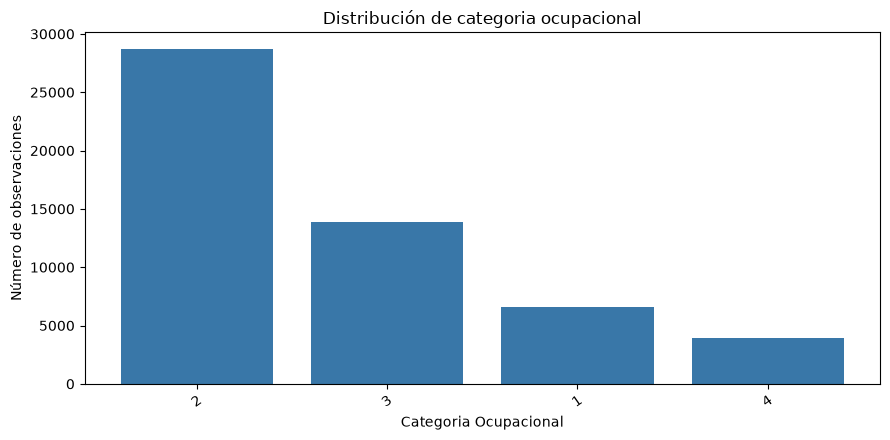

+---------------+-----+----------+
|nivel_educativo|count|porcentaje|
+---------------+-----+----------+
|4              |16851|31.78     |
|2              |15822|29.84     |
|3              |8249 |15.56     |
|5              |6818 |12.86     |
|0              |3995 |7.53      |
|6              |771  |1.45      |
|1              |459  |0.87      |
|7              |60   |0.11      |
+---------------+-----+----------+



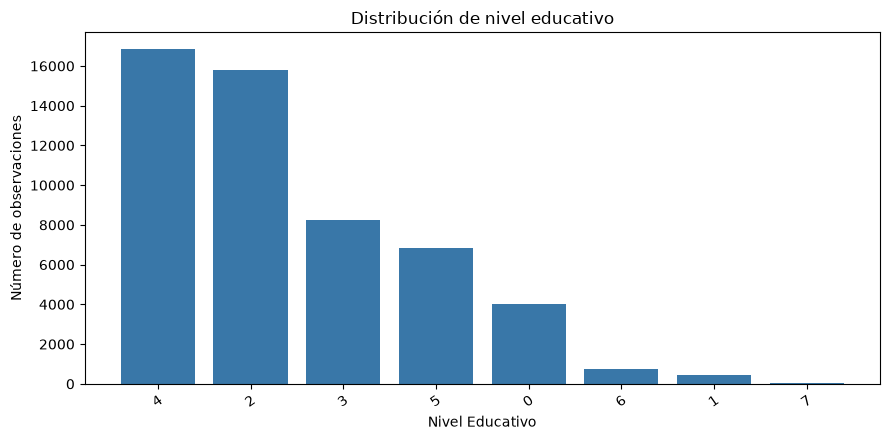

+-------+-----+----------+
|dominio|count|porcentaje|
+-------+-----+----------+
|1      |22072|41.63     |
|2      |20146|37.99     |
|3      |10807|20.38     |
+-------+-----+----------+



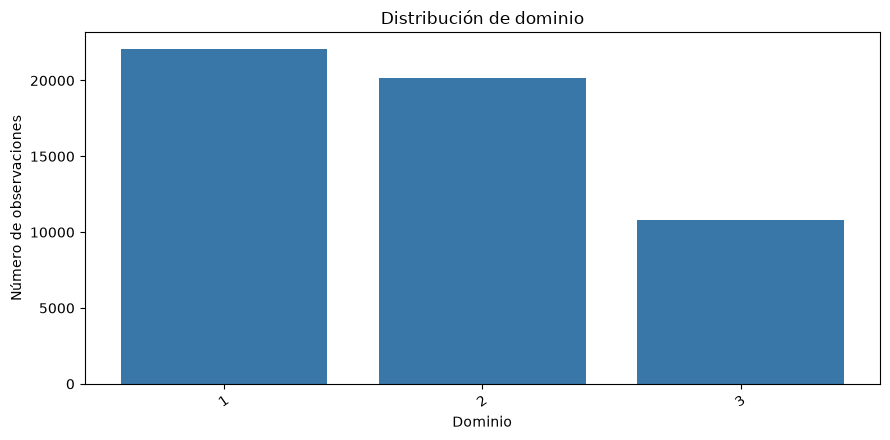

In [13]:
def category_distribution(frame, column):
    total = frame.count()
    return (frame.groupBy(column).count()
        .withColumn('porcentaje', F.round(F.lit(100.0) * F.col('count') / F.lit(total), 2))
        .orderBy(F.desc('count'), column))

def plot_aggregate(table, category, value, title, ylabel, color='#3977a8'):
    # La tabla agregada tiene pocas filas; es seguro llevarla a pandas para la gráfica.
    pdf = table.toPandas()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(pdf[category].astype(str), pdf[value], color=color)
    ax.set(title=title, xlabel=category.replace('_', ' ').title(), ylabel=ylabel)
    ax.tick_params(axis='x', rotation=35)
    plt.tight_layout()
    plt.show()

category_tables = {}
for categorical in ['categoria_ocupacional', 'nivel_educativo', 'dominio']:
    category_tables[categorical] = category_distribution(analysis_2025, categorical)
    category_tables[categorical].show(truncate=False)
    plot_aggregate(category_tables[categorical], categorical, 'count',
                   f'Distribución de {categorical.replace(chr(95), chr(32))}',
                   'Número de observaciones')

## Distribución salarial y comparaciones

La media y la mediana se contrastan porque una media claramente superior a la mediana evidencia asimetría positiva: pocos salarios altos desplazan el promedio. El percentil 95 y el máximo permiten identificar esos extremos sin eliminarlos.

Media: Q3,421.68; mediana: Q3,000.00; P95: Q8,000.00; máximo: Q99,000.00
Interpretación: la distribución presenta asimetría positiva; los salarios altos elevan la media.


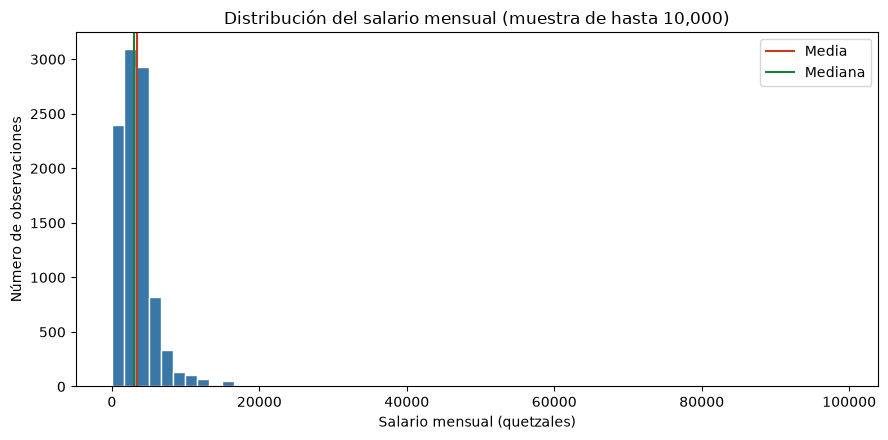

+---------------+-------------+---------------+
|nivel_educativo|observaciones|salario_mediano|
+---------------+-------------+---------------+
|7              |60           |12000.0        |
|6              |771          |10000.0        |
|5              |6818         |5000.0         |
|4              |16851        |3600.0         |
|3              |8249         |2800.0         |
|2              |15822        |2200.0         |
|1              |459          |2160.0         |
|0              |3995         |1500.0         |
+---------------+-------------+---------------+



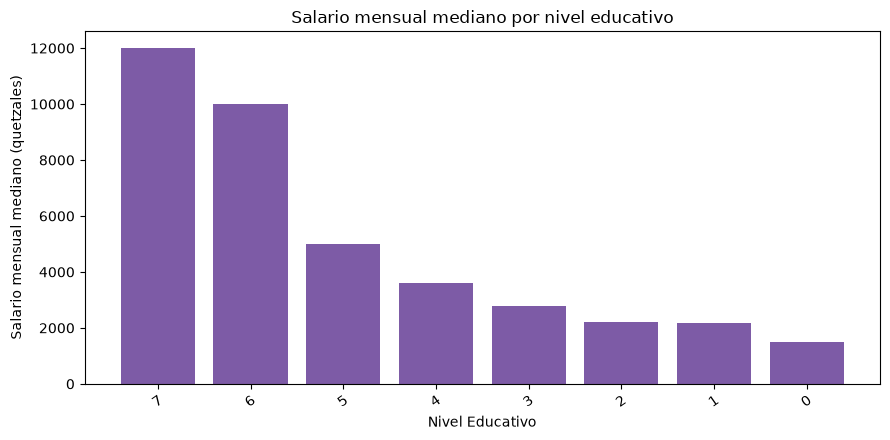

+---------------------+-------------+---------------+
|categoria_ocupacional|observaciones|salario_mediano|
+---------------------+-------------+---------------+
|1                    |6575         |5000.0         |
|2                    |28702        |3560.0         |
|3                    |13842        |1800.0         |
|4                    |3906         |1000.0         |
+---------------------+-------------+---------------+



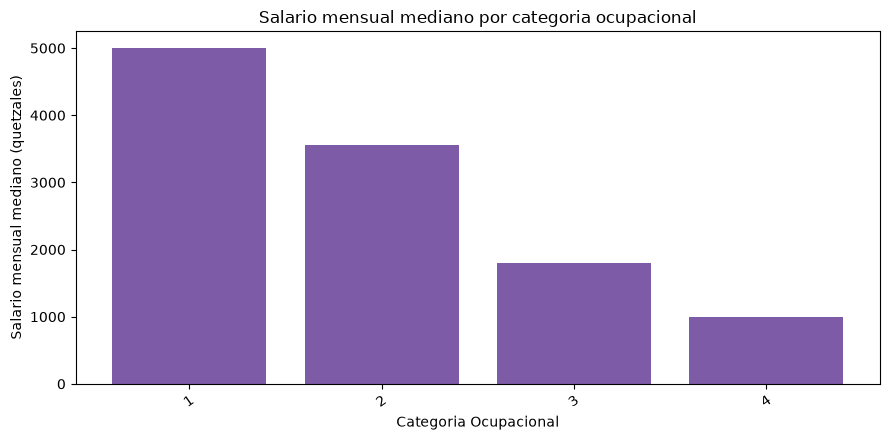

In [14]:
salary_summary = statistics_table.where(F.col('variable') == 'salario_mensual').first().asDict()
print(f"Media: Q{salary_summary['media']:,.2f}; mediana: Q{salary_summary['mediana']:,.2f}; P95: Q{salary_summary['p95']:,.2f}; máximo: Q{salary_summary['maximo']:,.2f}")
if salary_summary['media'] > salary_summary['mediana']:
    print('Interpretación: la distribución presenta asimetría positiva; los salarios altos elevan la media.')
else:
    print('Interpretación: la media no supera la mediana; revisar el histograma y percentiles antes de concluir sobre la asimetría.')

# Muestra reproducible y acotada solo para visualizar; las tablas y métricas anteriores usan todos los registros.
salary_plot_sample = analysis_2025.select('salario_mensual').orderBy(F.rand(seed=2026)).limit(10000).toPandas()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(salary_plot_sample['salario_mensual'], bins=60, color='#3977a8', edgecolor='white')
ax.axvline(salary_summary['media'], color='#c23b22', label='Media')
ax.axvline(salary_summary['mediana'], color='#1b7f3a', label='Mediana')
ax.set(title='Distribución del salario mensual (muestra de hasta 10,000)', xlabel='Salario mensual (quetzales)', ylabel='Número de observaciones')
ax.legend()
plt.tight_layout()
plt.show()

def median_salary_by(frame, group):
    return (frame.groupBy(group)
        .agg(F.count('*').alias('observaciones'), F.expr('percentile_approx(salario_mensual, 0.5, 10000)').alias('salario_mediano'))
        .orderBy(F.desc('salario_mediano')))

for group in ['nivel_educativo', 'categoria_ocupacional']:
    comparison = median_salary_by(analysis_2025, group)
    comparison.show(truncate=False)
    plot_aggregate(comparison, group, 'salario_mediano', f'Salario mensual mediano por {group.replace(chr(95), chr(32))}', 'Salario mensual mediano (quetzales)', '#7d5ba6')

+---------------+-------------+---------------+
|periodo_archivo|observaciones|salario_mediano|
+---------------+-------------+---------------+
|2025T1         |13419        |3000.0         |
|2025T2         |13492        |3000.0         |
|2025T3         |13450        |3200.0         |
|2025T4         |12664        |3200.0         |
+---------------+-------------+---------------+



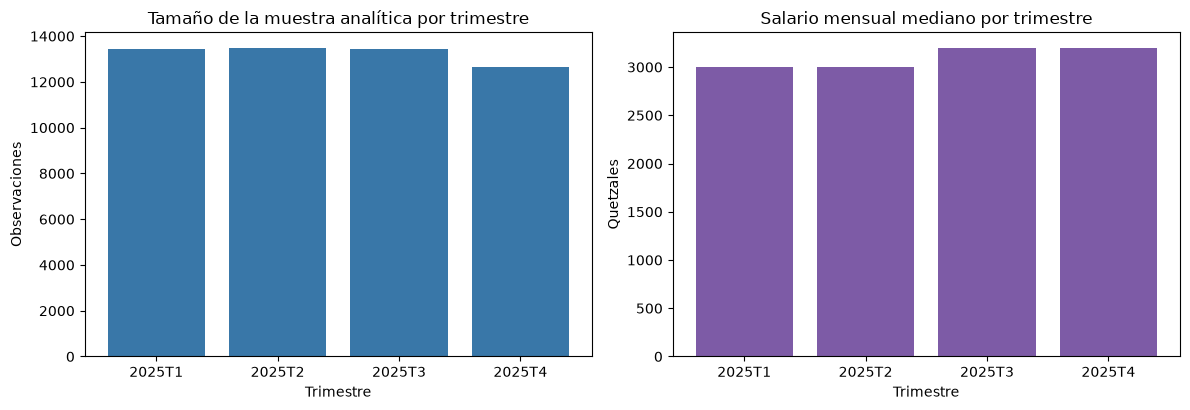

Interpretar las diferencias trimestrales junto con el tamaño muestral mostrado; no implican por sí solas cambios poblacionales.


In [15]:
quarter_comparison = (analysis_2025.groupBy('periodo_archivo')
    .agg(F.count('*').alias('observaciones'), F.expr('percentile_approx(salario_mensual, 0.5, 10000)').alias('salario_mediano'))
    .orderBy('periodo_archivo'))
quarter_comparison.show(truncate=False)

quarter_pdf = quarter_comparison.toPandas()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(quarter_pdf['periodo_archivo'], quarter_pdf['observaciones'], color='#3977a8')
axes[0].set(title='Tamaño de la muestra analítica por trimestre', xlabel='Trimestre', ylabel='Observaciones')
axes[1].bar(quarter_pdf['periodo_archivo'], quarter_pdf['salario_mediano'], color='#7d5ba6')
axes[1].set(title='Salario mensual mediano por trimestre', xlabel='Trimestre', ylabel='Quetzales')
plt.tight_layout()
plt.show()
print('Interpretar las diferencias trimestrales junto con el tamaño muestral mostrado; no implican por sí solas cambios poblacionales.')

## Correlación de Pearson

La correlación mide asociación lineal, no causalidad. Se calcula con `VectorAssembler` y `Correlation.corr()` sobre todos los registros preparados.

+---------------+-------------------+--------------------+---------------------+---------------------+
|variable       |salario_mensual    |edad                |antiguedad           |horas_semanales      |
+---------------+-------------------+--------------------+---------------------+---------------------+
|salario_mensual|1.0                |0.14724925920743273 |0.17957441272782343  |0.07566511338027686  |
|edad           |0.14724925920743273|1.0                 |0.48671275588216223  |-0.10537763199204009 |
|antiguedad     |0.17957441272782343|0.48671275588216223 |1.0                  |-0.062255609101473264|
|horas_semanales|0.07566511338027686|-0.10537763199204009|-0.062255609101473264|1.0                  |
+---------------+-------------------+--------------------+---------------------+---------------------+



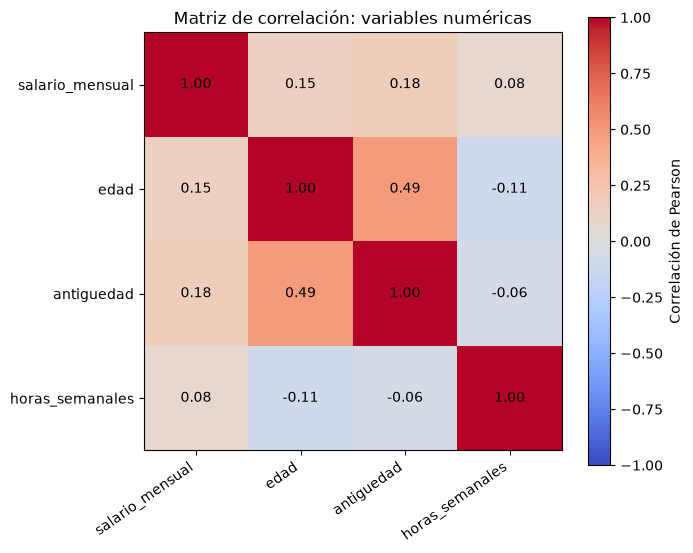

Valores cercanos a 1 o -1 indican asociación lineal fuerte; valores cercanos a 0, asociación lineal débil.


In [16]:
correlation_assembler = VectorAssembler(inputCols=NUMERIC_ANALYSIS, outputCol='correlation_features')
correlation_frame = correlation_assembler.transform(analysis_2025).select('correlation_features')
correlation_matrix = Correlation.corr(correlation_frame, 'correlation_features', method='pearson').first()[0].toArray()
correlation_rows = [(NUMERIC_ANALYSIS[i], *[float(correlation_matrix[i, j]) for j in range(len(NUMERIC_ANALYSIS))]) for i in range(len(NUMERIC_ANALYSIS))]
correlation_table = spark.createDataFrame(correlation_rows, ['variable', *NUMERIC_ANALYSIS])
correlation_table.show(truncate=False)

fig, ax = plt.subplots(figsize=(7, 5.8))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap='coolwarm')
ax.set_xticks(range(len(NUMERIC_ANALYSIS)), NUMERIC_ANALYSIS, rotation=35, ha='right')
ax.set_yticks(range(len(NUMERIC_ANALYSIS)), NUMERIC_ANALYSIS)
for i in range(len(NUMERIC_ANALYSIS)):
    for j in range(len(NUMERIC_ANALYSIS)):
        ax.text(j, i, f'{correlation_matrix[i, j]:.2f}', ha='center', va='center')
fig.colorbar(image, ax=ax, label='Correlación de Pearson')
ax.set_title('Matriz de correlación: variables numéricas')
plt.tight_layout()
plt.show()
print('Valores cercanos a 1 o -1 indican asociación lineal fuerte; valores cercanos a 0, asociación lineal débil.')

## Segmentación con KMeans

Los clusters se forman con edad, antigüedad y horas semanales, no con salario. Así el salario queda como resultado para interpretar perfiles laborales y no define artificialmente los grupos que luego se comparan por ingreso. Las tres variables se estandarizan porque tienen escalas distintas.

+---+-------------------+
|k  |silhouette         |
+---+-------------------+
|2  |0.5544815141856191 |
|3  |0.442971934726464  |
|4  |0.47577512213161005|
|5  |0.48821076299391497|
+---+-------------------+

K seleccionado: 2. Se prioriza el mayor silhouette; si la diferencia es mínima, se prefiere el K más pequeño e interpretable.


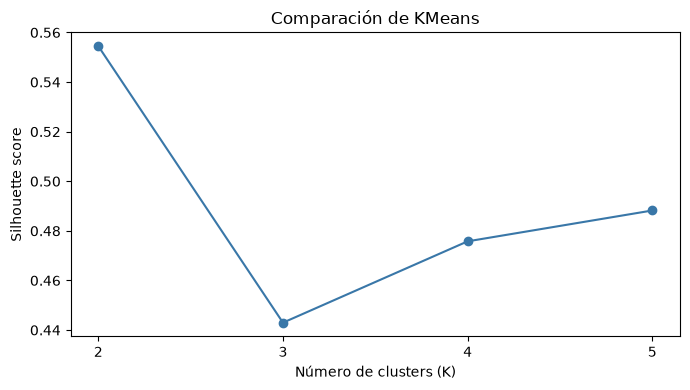

In [17]:
CLUSTER_FEATURES = ['edad', 'antiguedad', 'horas_semanales']
CLUSTER_SEED = 2026
cluster_assembler = VectorAssembler(inputCols=CLUSTER_FEATURES, outputCol='cluster_features_raw')
cluster_scaler = StandardScaler(inputCol='cluster_features_raw', outputCol='cluster_features', withMean=True, withStd=True)
cluster_preparation = Pipeline(stages=[cluster_assembler, cluster_scaler]).fit(analysis_2025)
cluster_features_frame = cluster_preparation.transform(analysis_2025).cache()

evaluator = ClusteringEvaluator(featuresCol='cluster_features', predictionCol='cluster', metricName='silhouette', distanceMeasure='squaredEuclidean')
kmeans_results = []
clustered_by_k = {}
for k in [2, 3, 4, 5]:
    model = KMeans(k=k, seed=CLUSTER_SEED, featuresCol='cluster_features', predictionCol='cluster').fit(cluster_features_frame)
    clustered = model.transform(cluster_features_frame).cache()
    kmeans_results.append((k, float(evaluator.evaluate(clustered))))
    clustered_by_k[k] = clustered

kmeans_comparison = spark.createDataFrame(kmeans_results, ['k', 'silhouette']).orderBy('k')
kmeans_comparison.show(truncate=False)
best_k = kmeans_comparison.orderBy(F.desc('silhouette'), 'k').first()['k']
print(f'K seleccionado: {best_k}. Se prioriza el mayor silhouette; si la diferencia es mínima, se prefiere el K más pequeño e interpretable.')

kmeans_pdf = kmeans_comparison.toPandas()
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kmeans_pdf['k'], kmeans_pdf['silhouette'], marker='o', color='#3977a8')
ax.set(title='Comparación de KMeans', xlabel='Número de clusters (K)', ylabel='Silhouette score')
ax.set_xticks([2, 3, 4, 5])
plt.tight_layout()
plt.show()

In [18]:
best_clustered = clustered_by_k[best_k]
cluster_profile = (best_clustered.groupBy('cluster')
    .agg(
        F.count('*').alias('tamano'),
        *[F.mean(column).alias(f'media_{column}') for column in [*CLUSTER_FEATURES, 'salario_mensual']],
        *[F.expr(f'percentile_approx({column}, 0.5, 10000)').alias(f'mediana_{column}') for column in [*CLUSTER_FEATURES, 'salario_mensual']],
    )
    .orderBy('cluster'))
cluster_profile.show(truncate=False)

# Esta tabla permite describir cada grupo por su tamaño, edad, antigüedad, jornada y salario observado.
# Los nombres descriptivos deben asignarse después de revisar estas medias y medianas, no por el identificador numérico del cluster.
print('Descripción sugerida: identificar para cada cluster si concentra trabajadores de menor/mayor edad, menor/mayor antigüedad y jornadas más cortas/largas; después contrastar su salario mediano.')

+-------+------+------------------+------------------+---------------------+---------------------+------------+------------------+-----------------------+-----------------------+
|cluster|tamano|media_edad        |media_antiguedad  |media_horas_semanales|media_salario_mensual|mediana_edad|mediana_antiguedad|mediana_horas_semanales|mediana_salario_mensual|
+-------+------+------------------+------------------+---------------------+---------------------+------------+------------------+-----------------------+-----------------------+
|0      |14604 |51.279101615995614|13.805024879028577|41.29553546973432    |4068.515269789099    |51.0        |13.0              |40.0                   |3456.0                 |
|1      |38421 |29.071211056453503|2.424409827958667 |48.21243590744645    |3175.8207230420862   |28.0        |1.3333333333333333|46.0                   |3000.0                 |
+-------+------+------------------+------------------+---------------------+---------------------+-------

# Modelado y validación (Persona 3)

El avance usa únicamente las observaciones preparadas de 2025. Se asigna aproximadamente el 80 % a entrenamiento y el 20 % a validación mediante un hash reproducible de las claves de registro y la semilla fija `2026`. Todos los modelos y la referencia usan esta misma división. El período 2026T1 no participa en la selección de modelos.

In [19]:
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor

MODEL_SEED = 2026
TRAIN_FRACTION = 0.80
TARGET = 'salario_mensual'
NUMERIC_FEATURES = ['edad', 'antiguedad', 'horas_semanales']
CATEGORICAL_FEATURES = ['nivel_educativo', 'categoria_ocupacional', 'dominio']

# Permite ejecutar esta sección en una sesión nueva después de ejecutar la primera celda del notebook.
if 'data_2025_prepared' not in globals():
    data_2025_prepared = spark.read.parquet(str(PROJECT_ROOT / 'data' / 'processed' / 'personas_2025_preparado'))

model_data_2025 = data_2025_prepared.select(
    TARGET, *NUMERIC_FEATURES, *CATEGORICAL_FEATURES,
    'periodo_archivo', 'NUM_HOGAR', 'NUM_PERSONA',
)
split_bucket = F.pmod(F.xxhash64(
    F.lit(MODEL_SEED), F.col('periodo_archivo'), F.col('NUM_HOGAR'), F.col('NUM_PERSONA')
), F.lit(100))
train_2025 = model_data_2025.where(split_bucket < int(TRAIN_FRACTION * 100))
validation_2025 = model_data_2025.where(split_bucket >= int(TRAIN_FRACTION * 100))
train_2025 = train_2025.cache()
validation_2025 = validation_2025.cache()
n_train, n_validation = train_2025.count(), validation_2025.count()
if n_train == 0 or n_validation == 0:
    raise ValueError('La división produjo un conjunto vacío; revisar los datos preparados de 2025.')
print(f'División 2025: {n_train:,} entrenamiento ({n_train / (n_train + n_validation):.1%}) y '
      f'{n_validation:,} validación ({n_validation / (n_train + n_validation):.1%}); semilla {MODEL_SEED}.')

evaluators = {
    'mae': RegressionEvaluator(labelCol=TARGET, predictionCol='prediction', metricName='mae'),
    'rmse': RegressionEvaluator(labelCol=TARGET, predictionCol='prediction', metricName='rmse'),
    'r2': RegressionEvaluator(labelCol=TARGET, predictionCol='prediction', metricName='r2'),
}

def regression_metrics(predictions):
    predictions = predictions.select(TARGET, 'prediction').cache()
    try:
        return {name: float(evaluator.evaluate(predictions)) for name, evaluator in evaluators.items()}
    finally:
        predictions.unpersist()

train_mean_salary = train_2025.agg(F.avg(TARGET).alias('media')).first()['media']
baseline_predictions = validation_2025.withColumn('prediction', F.lit(float(train_mean_salary)))
baseline_metrics = regression_metrics(baseline_predictions)
results = [{
    'modelo': 'Referencia: media de entrenamiento',
    'configuracion': 'media 2025 entrenamiento',
    'parametros': f'media = Q{train_mean_salary:,.2f}',
    **baseline_metrics,
}]
print(f'Referencia: predecir Q{train_mean_salary:,.2f} para cada registro de validación.')
print(f"MAE = Q{baseline_metrics['mae']:,.2f}; RMSE = Q{baseline_metrics['rmse']:,.2f}; R² = {baseline_metrics['r2']:.4f}.")

División 2025: 42,419 entrenamiento (80.0%) y 10,606 validación (20.0%); semilla 2026.
Referencia: predecir Q3,412.52 para cada registro de validación.
MAE = Q1,726.05; RMSE = Q2,960.75; R² = -0.0002.


## Pipelines supervisados

Ambos modelos ajustan los índices y la codificación categórica **solo con entrenamiento**. `handleInvalid='keep'` permite transformar categorías no vistas en validación. Se usan edad, antigüedad y horas semanales junto con nivel educativo, categoría ocupacional y dominio. La regresión lineal usa su estandarización interna; Random Forest conserva los valores numéricos originales.

In [20]:
def preprocessing_stages():
    indexed = [f'{name}_index' for name in CATEGORICAL_FEATURES]
    encoded = [f'{name}_ohe' for name in CATEGORICAL_FEATURES]
    return [
        StringIndexer(inputCols=CATEGORICAL_FEATURES, outputCols=indexed, handleInvalid='keep'),
        OneHotEncoder(inputCols=indexed, outputCols=encoded, handleInvalid='keep'),
        VectorAssembler(inputCols=[*NUMERIC_FEATURES, *encoded], outputCol='features'),
    ]

linear_configurations = [
    {'regParam': 0.0, 'elasticNetParam': 0.0},
    {'regParam': 10.0, 'elasticNetParam': 0.0},
    {'regParam': 100.0, 'elasticNetParam': 0.0},
]
forest_configurations = [
    {'numTrees': 40, 'maxDepth': 5},
    {'numTrees': 80, 'maxDepth': 8},
]

selected_models = {}
selected_results = {}

for model_name, configurations in [
    ('Regresión lineal', linear_configurations),
    ('Random Forest', forest_configurations),
]:
    for index, parameters in enumerate(configurations, start=1):
        if model_name == 'Regresión lineal':
            estimator = LinearRegression(
                labelCol=TARGET, featuresCol='features', predictionCol='prediction',
                standardization=True, maxIter=100, **parameters,
            )
        else:
            estimator = RandomForestRegressor(
                labelCol=TARGET, featuresCol='features', predictionCol='prediction',
                seed=MODEL_SEED, **parameters,
            )

        pipeline = Pipeline(stages=[*preprocessing_stages(), estimator])
        fitted_pipeline = pipeline.fit(train_2025)
        metrics = regression_metrics(fitted_pipeline.transform(validation_2025))
        row = {
            'modelo': model_name,
            'configuracion': f'{model_name} {index}',
            'parametros': ', '.join(f'{key}={value}' for key, value in parameters.items()),
            **metrics,
        }
        results.append(row)
        print(f"{row['configuracion']}: {row['parametros']} | MAE=Q{row['mae']:,.2f}, "
              f"RMSE=Q{row['rmse']:,.2f}, R²={row['r2']:.4f}")
        if model_name not in selected_results or row['rmse'] < selected_results[model_name]['rmse']:
            selected_results[model_name] = row
            selected_models[model_name] = fitted_pipeline

from IPython.display import display
validation_comparison = pd.DataFrame(results)[
    ['modelo', 'configuracion', 'parametros', 'mae', 'rmse', 'r2']
].sort_values('rmse').reset_index(drop=True)
display(validation_comparison)

for model_name, row in selected_results.items():
    print(f"Seleccionado para {model_name}: {row['configuracion']} por menor RMSE de validación "
          f"(Q{row['rmse']:,.2f}).")

Regresión lineal 1: regParam=0.0, elasticNetParam=0.0 | MAE=Q1,253.34, RMSE=Q2,227.36, R²=0.4339
Regresión lineal 2: regParam=10.0, elasticNetParam=0.0 | MAE=Q1,252.89, RMSE=Q2,227.50, R²=0.4338
Regresión lineal 3: regParam=100.0, elasticNetParam=0.0 | MAE=Q1,249.35, RMSE=Q2,229.04, R²=0.4331
Random Forest 1: numTrees=40, maxDepth=5 | MAE=Q1,209.84, RMSE=Q2,221.12, R²=0.4371
Random Forest 2: numTrees=80, maxDepth=8 | MAE=Q1,137.62, RMSE=Q2,093.64, R²=0.4998


,modelo,configuracion,parametros,mae,rmse,r2
0,Random Forest,Random Forest 2,"numTrees=80, maxDepth=8",1137.620305,2093.643139,0.499842
1,Random Forest,Random Forest 1,"numTrees=40, maxDepth=5",1209.841149,2221.118222,0.437082
2,Regresión lineal,Regresión lineal 1,"regParam=0.0, elasticNetParam=0.0",1253.335895,2227.363792,0.433912
3,Regresión lineal,Regresión lineal 2,"regParam=10.0, elasticNetParam=0.0",1252.891734,2227.495231,0.433845
4,Regresión lineal,Regresión lineal 3,"regParam=100.0, elasticNetParam=0.0",1249.353707,2229.042811,0.433058
5,Referencia: media de entrenamiento,media 2025 entrenamiento,"media = Q3,412.52",1726.049066,2960.745614,-0.000239


Seleccionado para Regresión lineal: Regresión lineal 1 por menor RMSE de validación (Q2,227.36).
Seleccionado para Random Forest: Random Forest 2 por menor RMSE de validación (Q2,093.64).


## Comparación y guardado del avance

Con los archivos actuales quedaron 42,419 observaciones de entrenamiento y 10,606 de validación de 2025. La siguiente tabla registra las configuraciones evaluadas; MAE y RMSE están expresados en quetzales por mes y R² no tiene unidades.

| Modelo | Configuración | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| Referencia (media del entrenamiento) | Q3,412.52 constante | Q1,726.05 | Q2,960.75 | -0.0002 |
| Regresión lineal | regParam=0, elasticNetParam=0 | Q1,253.34 | Q2,227.36 | 0.4339 |
| Regresión lineal | regParam=10, elasticNetParam=0 | Q1,252.89 | Q2,227.50 | 0.4338 |
| Regresión lineal | regParam=100, elasticNetParam=0 | Q1,249.35 | Q2,229.04 | 0.4331 |
| Random Forest | numTrees=40, maxDepth=5 | Q1,209.84 | Q2,221.12 | 0.4371 |
| Random Forest | numTrees=80, maxDepth=8 | Q1,137.62 | **Q2,093.64** | 0.4998 |

Se elige la regresión lineal sin regularización y el Random Forest de 80 árboles y profundidad 8 por su menor RMSE dentro de cada algoritmo. Random Forest también supera a la referencia. Su capacidad de representar umbrales e interacciones puede explicar la mejora respecto de un modelo lineal aditivo, aunque esta comparación no demuestra causalidad. Los `PipelineModel` completos se guardan a continuación. Estos resultados son únicamente de validación de 2025; la evaluación de 2026T1 corresponde a la entrega final.

In [21]:
model_dir = PROJECT_ROOT / 'models' / 'avance_2025'
model_dir.mkdir(parents=True, exist_ok=True)
model_paths = {
    'Regresión lineal': model_dir / 'regresion_lineal',
    'Random Forest': model_dir / 'random_forest',
}
for model_name, fitted_pipeline in selected_models.items():
    fitted_pipeline.write().overwrite().save(str(model_paths[model_name]))
    print(f'Pipeline guardado: {model_paths[model_name]}')

best_name = min(selected_results, key=lambda name: selected_results[name]['rmse'])
best_row = selected_results[best_name]
reference_rmse = baseline_metrics['rmse']
print(f"Mejor modelo supervisado en validación: {best_name} "
      f"(RMSE Q{best_row['rmse']:,.2f}; referencia Q{reference_rmse:,.2f}).")
if best_row['rmse'] < reference_rmse:
    print('La mejora frente a la referencia indica que las variables contienen señal predictiva en esta división de 2025.')
else:
    print('Ningún modelo supervisado mejora la referencia en RMSE; revisar las variables y configuraciones antes de concluir.')
if best_name == 'Random Forest':
    print('Random Forest puede captar umbrales e interacciones que la relación lineal aditiva no representa directamente.')
else:
    print('La regresión lineal puede rendir mejor cuando la señal es aproximadamente aditiva o el bosque añade variabilidad sin reducir el error.')
print('La comparación es predictiva y no demuestra causalidad; 2026T1 permanece reservado para la prueba final.')

Pipeline guardado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB07\models\avance_2025\regresion_lineal
Pipeline guardado: C:\Users\dijol\OneDrive\Documents\diego-drive\Universidad\Ciclo 8\Data Science\DS-LAB07\models\avance_2025\random_forest
Mejor modelo supervisado en validación: Random Forest (RMSE Q2,093.64; referencia Q2,960.75).
La mejora frente a la referencia indica que las variables contienen señal predictiva en esta división de 2025.
Random Forest puede captar umbrales e interacciones que la relación lineal aditiva no representa directamente.
La comparación es predictiva y no demuestra causalidad; 2026T1 permanece reservado para la prueba final.
